In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("C:\\Users\\Friends\\Downloads\\blinkit_data.csv")
df.head()


,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [3]:
# Grouped KPI data by Fat Content
fat_kpis = df.groupby('Item Fat Content').agg({
    'Sales': ['sum', 'mean'],
    'Item Identifier': 'count',
    'Rating': 'mean'
}).reset_index()

fat_kpis.columns = ['Fat Content', 'Total Sales', 'Average Sales', 'Number of Items', 'Average Rating']
fat_kpis


,Fat Content,Total Sales,Average Sales,Number of Items,Average Rating
0,LF,43857.1062,138.788311,316,3.868354
1,Low Fat,717390.8394,140.968921,5089,3.975025
2,Regular,409413.1214,141.714476,2889,3.962721
3,low fat,15071.7328,134.569043,112,3.845536
4,reg,15948.6810,136.313513,117,4.023077


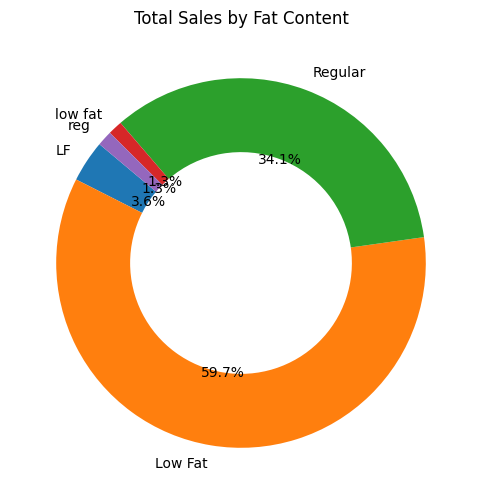

In [4]:
# Donut Chart - Total Sales by Fat Content
plt.figure(figsize=(6, 6))
plt.pie(
    fat_kpis['Total Sales'],
    labels=fat_kpis['Fat Content'],
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(width=0.4)
)
plt.title("Total Sales by Fat Content")
plt.show()


In [5]:
item_kpis = df.groupby('Item Type').agg({
    'Sales': ['sum', 'mean'],
    'Item Identifier': 'count',
    'Rating': 'mean'
}).reset_index()

item_kpis.columns = ['Item Type', 'Total Sales', 'Average Sales', 'Number of Items', 'Average Rating']
item_kpis.head()


,Item Type,Total Sales,Average Sales,Number of Items,Average Rating
0,Baking Goods,81894.7364,126.380766,648,3.983025
1,Breads,35379.1198,140.952669,251,3.881275
2,Breakfast,15596.6966,141.788151,110,3.932727
3,Canned,90706.7270,139.763832,649,3.994299
4,Dairy,101276.4596,148.499208,682,3.965836


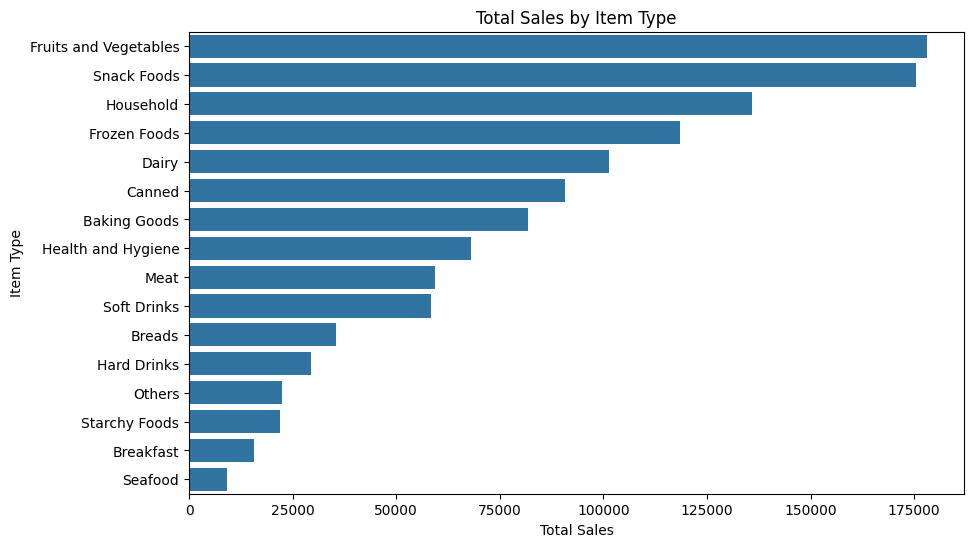

In [6]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Total Sales', y='Item Type', data=item_kpis.sort_values('Total Sales', ascending=False))
plt.title("Total Sales by Item Type")
plt.xlabel("Total Sales")
plt.ylabel("Item Type")
plt.show()


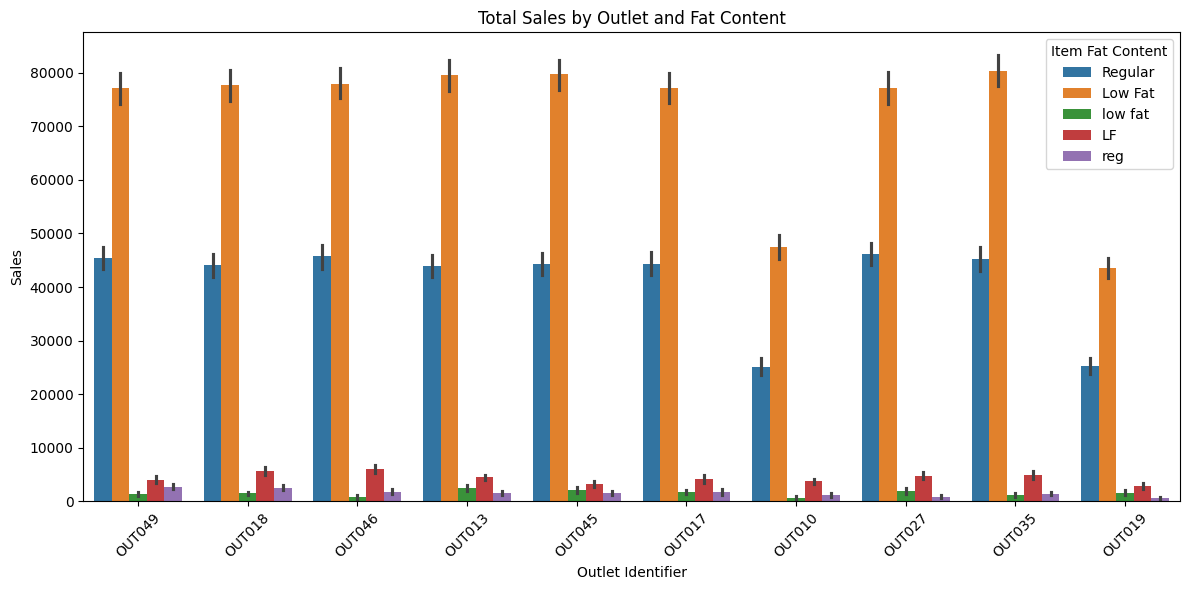

In [7]:
plt.figure(figsize=(12, 6))
sns.barplot(x='Outlet Identifier', y='Sales', hue='Item Fat Content', data=df, estimator=sum)
plt.title("Total Sales by Outlet and Fat Content")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


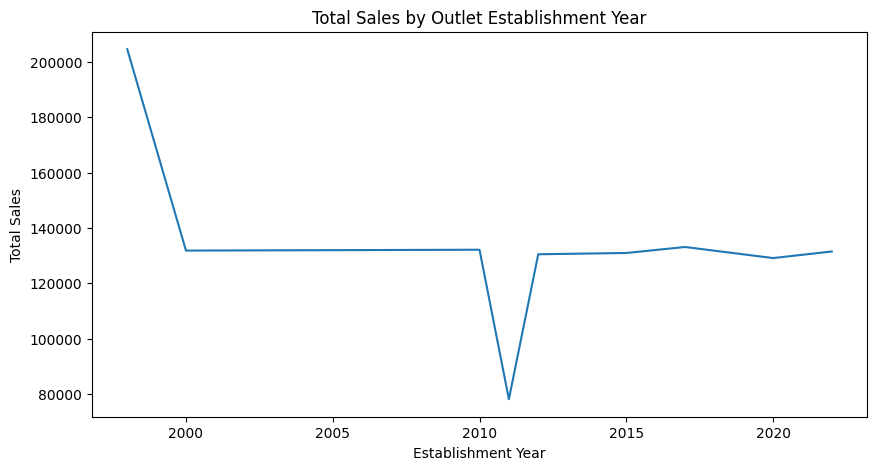

In [11]:
plt.figure(figsize=(10, 5))
sns.lineplot(
    x='Outlet Establishment Year',
    y='Sales',
    data=df,
    estimator=sum,
    errorbar=None  # use this instead of ci=None
)
plt.title("Total Sales by Outlet Establishment Year")
plt.ylabel("Total Sales")
plt.xlabel("Establishment Year")
plt.show()


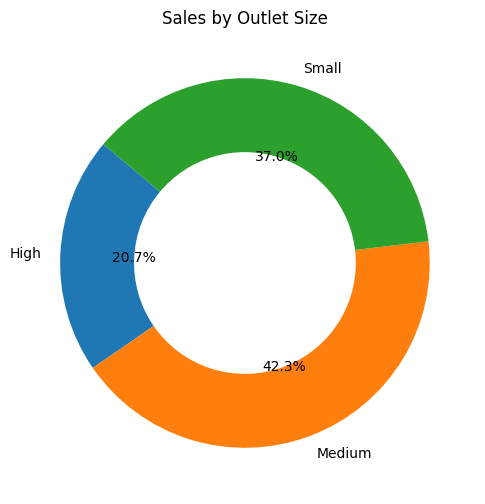

In [9]:
outlet_size_sales = df.groupby('Outlet Size')['Sales'].sum().reset_index()

plt.figure(figsize=(6, 6))
plt.pie(outlet_size_sales['Sales'], labels=outlet_size_sales['Outlet Size'], autopct='%1.1f%%', startangle=140, wedgeprops=dict(width=0.4))
plt.title("Sales by Outlet Size")
plt.show()


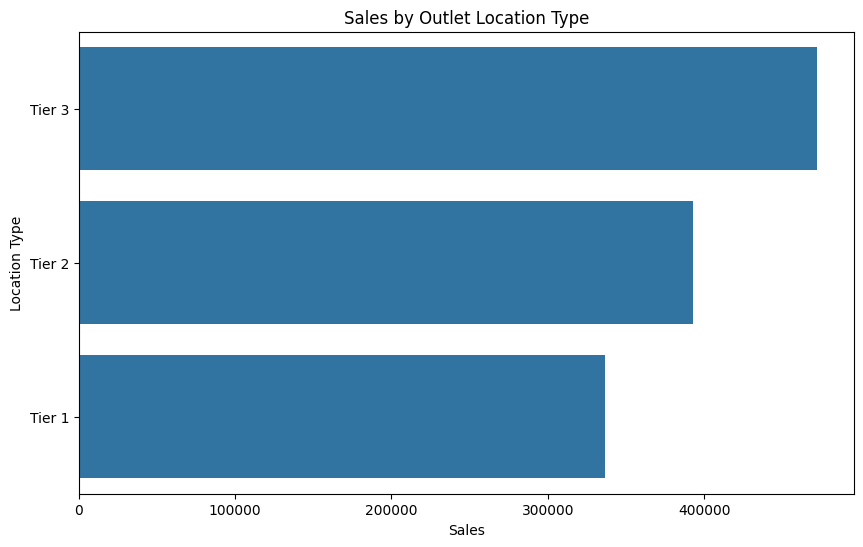

In [10]:
location_sales = df.groupby('Outlet Location Type')['Sales'].sum().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Sales', y='Outlet Location Type', data=location_sales.sort_values('Sales', ascending=False))
plt.title("Sales by Outlet Location Type")
plt.xlabel("Sales")
plt.ylabel("Location Type")
plt.show()
